<a href="https://colab.research.google.com/github/dahiyayogita77-ops/Task1-maincraft/blob/main/Task1_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

os.listdir()

['.config', 'Sample - Superstore.csv', 'sample_data']

In [2]:
import pandas as pd

import matplotlib.pyplot as plt

import plotly.express as px

import numpy as np

In [7]:
df = pd.read_csv(
    '/content/Sample - Superstore.csv',
    encoding='latin1'
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [9]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df = df.drop_duplicates()

In [12]:
df.shape

(9994, 21)

In [13]:
sales = df['Sales'].sum()

profit = df['Profit'].sum()

orders = df['Order ID'].nunique()

customers = df['Customer ID'].nunique()

print("Sales :",sales)

print("Profit :",profit)

print("Orders :",orders)

print("Customers :",customers)

Sales : 2297200.8603000003
Profit : 286397.0217
Orders : 5009
Customers : 793


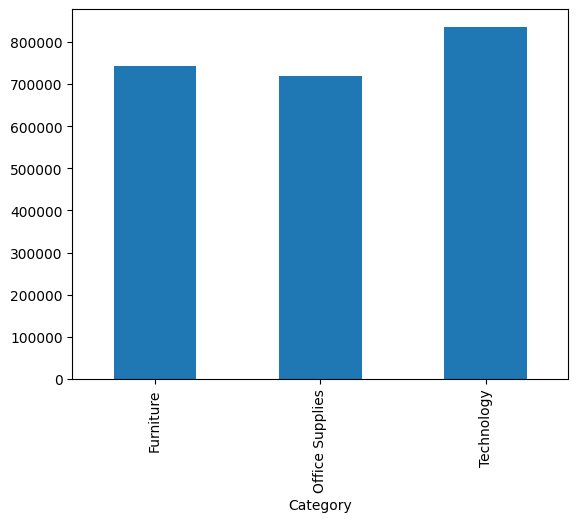

In [14]:
category = df.groupby(
'Category'
)['Sales'].sum()

category.plot(
kind='bar'
)

plt.show()

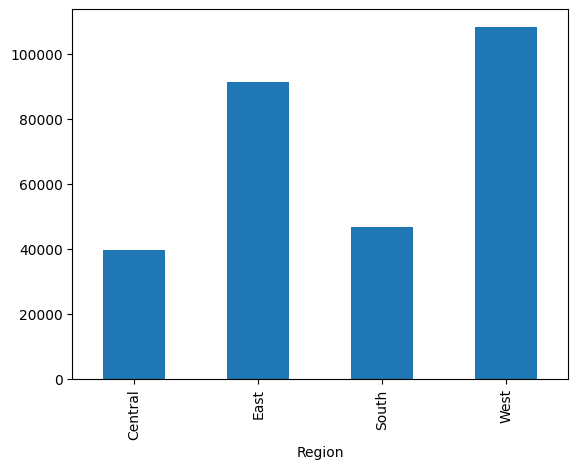

In [15]:
region=df.groupby(
'Region'
)['Profit'].sum()

region.plot(
kind='bar'
)

plt.show()

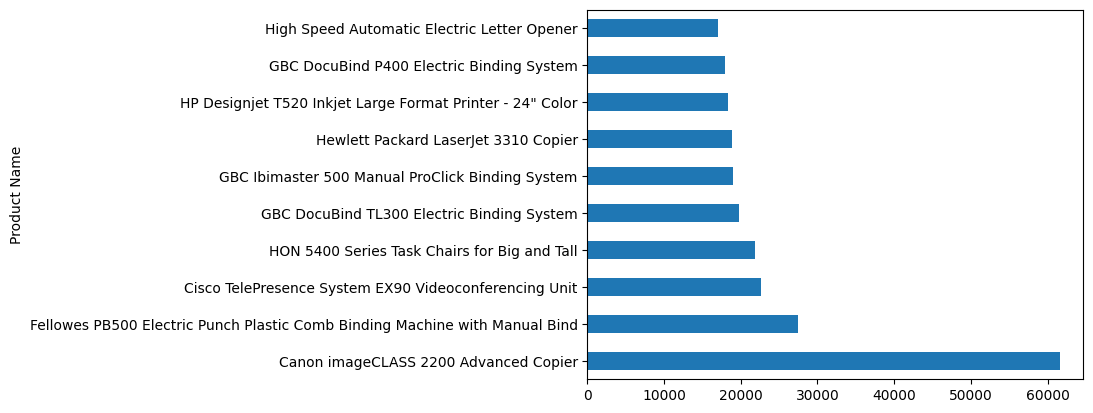

In [16]:
top = df.groupby(
'Product Name'
)['Sales'].sum()

top = top.sort_values(
ascending=False
)

top.head(10).plot(
kind='barh'
)

plt.show()

In [17]:
plt.savefig(
'sales_chart.png'
)

<Figure size 640x480 with 0 Axes>

In [19]:
plt.savefig(
'profit_chart.png'
)

<Figure size 640x480 with 0 Axes>

In [20]:
plt.savefig(
'top_products.png'
)

<Figure size 640x480 with 0 Axes>

In [21]:
df.to_csv(
'cleaned_superstore.csv',
index=False
)

In [22]:
from google.colab import files

files.download(
'cleaned_superstore.csv'
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
import sqlite3

In [24]:
conn = sqlite3.connect(
'superstore.db'
)

In [25]:
df.to_sql(
'sales',
conn,
if_exists='replace',
index=False
)

9994

In [26]:
query = '''

SELECT Category,

SUM(Sales)

FROM sales

GROUP BY Category

'''

pd.read_sql(
query,
conn
)

,Category,SUM(Sales)
0,Furniture,741999.7953
1,Office Supplies,719047.0320
2,Technology,836154.0330


In [27]:
query = '''

SELECT Region,

SUM(Profit)

FROM sales

GROUP BY Region

'''

pd.read_sql(
query,
conn
)

,Region,SUM(Profit)
0,Central,39706.3625
1,East,91522.7800
2,South,46749.4303
3,West,108418.4489


In [28]:
query='''

SELECT Segment,

COUNT(*)

FROM sales

GROUP BY Segment

'''

pd.read_sql(
query,
conn
)

,Segment,COUNT(*)
0,Consumer,5191
1,Corporate,3020
2,Home Office,1783
